# Steam Games Exploratory Data Analysis

This notebook explores the `steam_games.json` snapshot of Steam's store catalog. Each row describes a title with metadata such as genre, tags, price, discount status, release dates, review sentiment, and metascore. The goals are to understand data quality, pricing patterns, release trends, and the most common genres/tags represented in the dataset.

## Part 1: Steam catalog exploration

Understand the structure and pricing/release dynamics of the `steam_games.json` snapshot before building any predictive model.


In [1]:
import ast
import gzip
from itertools import islice
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 5)
DATA_PATH = Path('data/steam_games.json.gz')


In [2]:
from itertools import islice
import gzip

# read the first few lines of .json file
def peek_json_gz(path, n=3):
    """Return column names and sample rows from a JSON Lines gzip file."""
    with gzip.open(path, 'rt', encoding='utf-8') as f:
        sample = [ast.literal_eval(line) for line in islice(f, n)]
    columns = sorted({key for row in sample for key in row})
    return columns, sample


## Load and inspect the raw dataset

In [3]:
rows = []
with gzip.open(DATA_PATH, 'rt', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(ast.literal_eval(line))

df = pd.DataFrame(rows)
print(f"Loaded {len(df):,} games with {df.shape[1]} columns")
df.head()


Loaded 32,135 games with 16 columns


,publisher,genres,app_name,title,url,release_date,tags,discount_price,reviews_url,specs,price,early_access,id,developer,sentiment,metascore
0,Kotoshiro,"[Action, Casual, Indie, Simulation, Strategy]",Lost Summoner Kitty,Lost Summoner Kitty,http://store.steampowered.com/app/761140/Lost_...,2018-01-04,"[Strategy, Action, Indie, Casual, Simulation]",4.49,http://steamcommunity.com/app/761140/reviews/?...,[Single-player],4.99,False,761140,Kotoshiro,NaN,NaN
1,"Making Fun, Inc.","[Free to Play, Indie, RPG, Strategy]",Ironbound,Ironbound,http://store.steampowered.com/app/643980/Ironb...,2018-01-04,"[Free to Play, Strategy, Indie, RPG, Card Game...",NaN,http://steamcommunity.com/app/643980/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free To Play,False,643980,Secret Level SRL,Mostly Positive,NaN
2,Poolians.com,"[Casual, Free to Play, Indie, Simulation, Sports]",Real Pool 3D - Poolians,Real Pool 3D - Poolians,http://store.steampowered.com/app/670290/Real_...,2017-07-24,"[Free to Play, Simulation, Sports, Casual, Ind...",NaN,http://steamcommunity.com/app/670290/reviews/?...,"[Single-player, Multi-player, Online Multi-Pla...",Free to Play,False,670290,Poolians.com,Mostly Positive,NaN
3,彼岸领域,"[Action, Adventure, Casual]",弹炸人2222,弹炸人2222,http://store.steampowered.com/app/767400/2222/,2017-12-07,"[Action, Adventure, Casual]",0.83,http://steamcommunity.com/app/767400/reviews/?...,[Single-player],0.99,False,767400,彼岸领域,NaN,NaN
4,NaN,NaN,Log Challenge,NaN,http://store.steampowered.com/app/773570/Log_C...,NaN,"[Action, Indie, Casual, Sports]",1.79,http://steamcommunity.com/app/773570/reviews/?...,"[Single-player, Full controller support, HTC V...",2.99,False,773570,NaN,NaN,NaN


In [4]:
df.dtypes.to_frame('dtype')


,dtype
publisher,object
genres,object
app_name,object
title,object
url,object
release_date,object
tags,object
discount_price,float64
reviews_url,object
specs,object


In [5]:
# how many percent of entries are NaN in that column
missing_pct = df.isna().mean().mul(100).sort_values(ascending=False)
missing_pct.to_frame('pct_missing')


,pct_missing
discount_price,99.299829
metascore,91.669519
publisher,25.056792
sentiment,22.349463
developer,10.266065
genres,10.216275
release_date,6.432239
title,6.379337
price,4.285047
specs,2.084954


## Data cleaning and feature engineering

In [6]:
# converts various Steam price formats into clean floats
def parse_price(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return np.nan
        if value.lower().startswith('free'):
            return 0.0
        value = value.replace('$', '')
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan

df['price_numeric'] = df['price'].apply(parse_price)
df['discount_numeric'] = df['discount_price'].apply(lambda x: float(x) if pd.notnull(x) else np.nan)

# df['discount_pct']: how many percent off the game is
df['discount_pct'] = np.where(
    df['discount_numeric'].notna() & df['price_numeric'].notna() & (df['price_numeric'] > 0),
    (1 - df['discount_numeric'] / df['price_numeric']).clip(lower=0),
    np.nan, 
)
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['metascore'] = pd.to_numeric(df['metascore'], errors='coerce')

df[['price', 'price_numeric', 'discount_price', 'discount_numeric', 'discount_pct', 'release_date', 'metascore']].head()


,price,price_numeric,discount_price,discount_numeric,discount_pct,release_date,metascore
0,4.99,4.99,4.49,4.49,0.100200,2018-01-04,NaN
1,Free To Play,0.00,NaN,NaN,NaN,2018-01-04,NaN
2,Free to Play,0.00,NaN,NaN,NaN,2017-07-24,NaN
3,0.99,0.99,0.83,0.83,0.161616,2017-12-07,NaN
4,2.99,2.99,1.79,1.79,0.401338,NaT,NaN


## Pricing overview

In [7]:
price_summary = df['price_numeric'].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])
free_share = (df['price_numeric'] == 0).mean() * 100
paid_share = 100 - free_share
print(price_summary)
print(f'\nFree-to-play share: {free_share:.1f}% | Paid share: {paid_share:.1f}%')


count    30746.000000
mean         8.870315
std         15.905595
min          0.000000
25%          2.990000
50%          4.990000
75%          9.990000
90%         19.990000
95%         24.990000
max        995.000000
Name: price_numeric, dtype: float64

Free-to-play share: 5.9% | Paid share: 94.1%


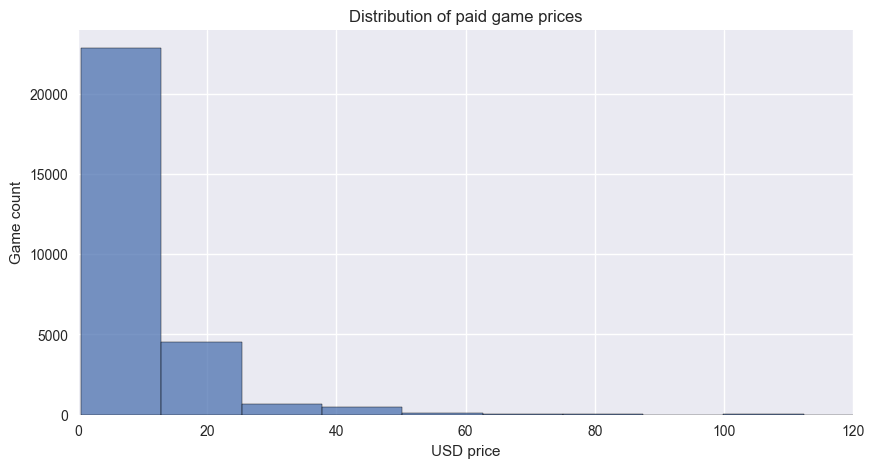

In [8]:
# histogram of paid Steam game prices
paid_prices = df.loc[df['price_numeric'] > 0, 'price_numeric']
fig, ax = plt.subplots()
sns.histplot(paid_prices, bins=80, ax=ax)
ax.set_title('Distribution of paid game prices')
ax.set_xlabel('USD price')
ax.set_ylabel('Game count')
ax.set_xlim(0, 120)
plt.show()


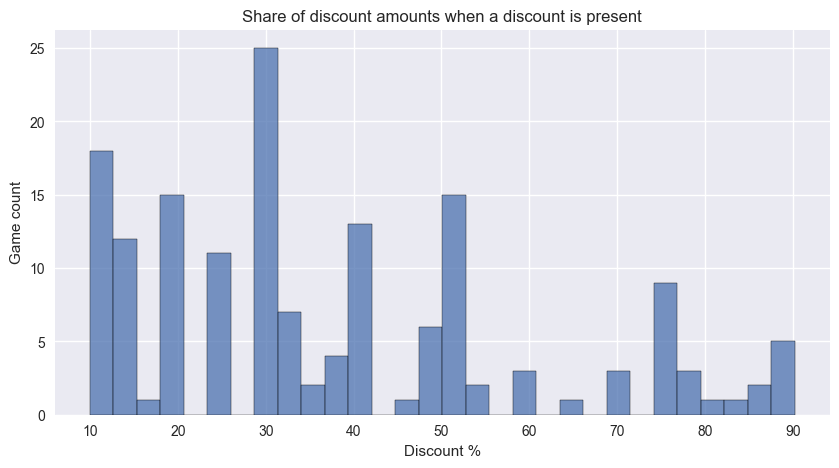

In [9]:
# histogram of discount percentages
fig, ax = plt.subplots()
sns.histplot(df['discount_pct'].dropna() * 100, bins=30, ax=ax)
ax.set_title('Share of discount amounts when a discount is present')
ax.set_xlabel('Discount %')
ax.set_ylabel('Game count')
plt.show()


## Review trends

In [10]:
# Counts of each Steam sentiment label, including low-review placeholders.
sentiment_counts = df['sentiment'].fillna('Unknown').value_counts()
sentiment_counts.to_frame('count')


,count
sentiment,
Unknown,7182
Mixed,4103
Very Positive,3868
Positive,3281
Mostly Positive,2744
1 user reviews,2496
2 user reviews,1756
3 user reviews,1231
4 user reviews,964


## Genres, tags, and specs

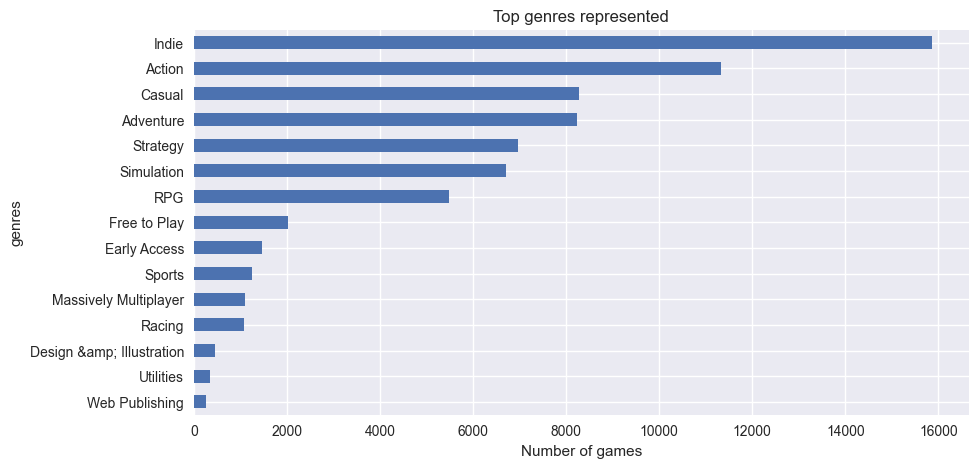

In [11]:
# 15 most common game genres on Steam
genre_counts = df['genres'].dropna().explode().value_counts().head(15)
fig, ax = plt.subplots()
genre_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Number of games')
ax.set_title('Top genres represented')
plt.show()


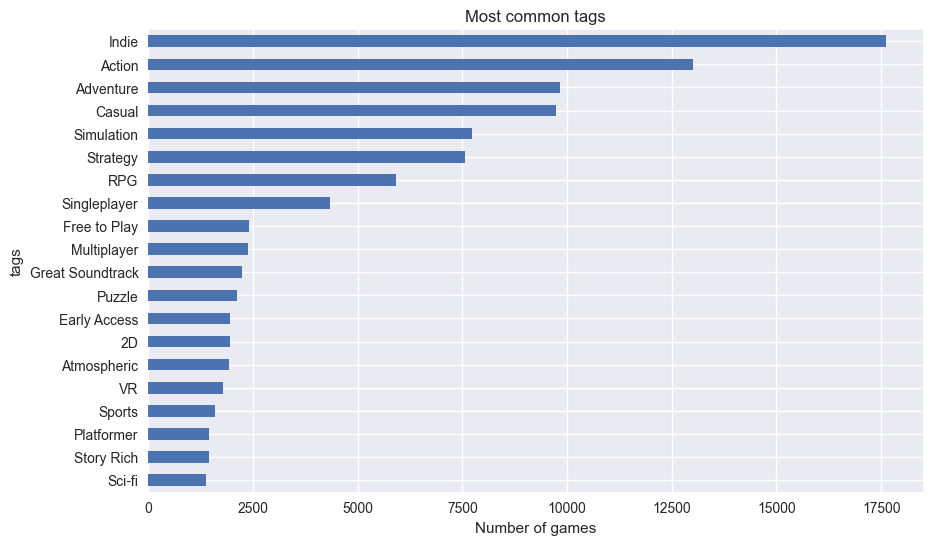

In [12]:
# 20 most common game tags on Steam
tag_counts = df['tags'].dropna().explode().value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 6))
tag_counts.sort_values().plot(kind='barh', ax=ax)
ax.set_xlabel('Number of games')
ax.set_title('Most common tags')
plt.show()


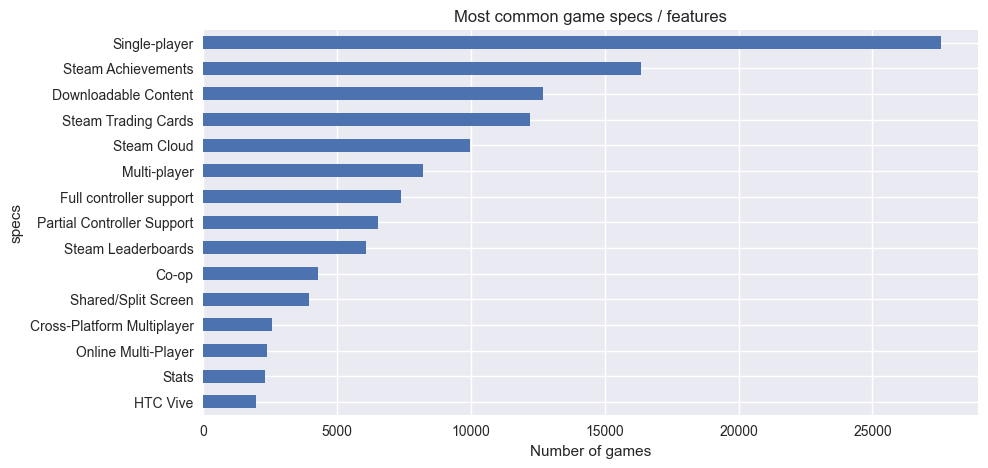

In [13]:
# 15 most common gameplay/technical features (specs)
spec_counts = df['specs'].dropna().explode().value_counts().head(15)
ax = spec_counts.sort_values().plot(kind='barh')
ax.set_xlabel('Number of games')
ax.set_title('Most common game specs / features')
plt.show()


## Part 2: Review data preparation and modeling

Flatten the review snapshots, engineer per-game and per-user features, and build the recommendation predictor.


## User review recommendation analysis

Examine recommendation behavior within the Australian user review snapshot and relate it to Steam catalog features.


In [14]:
# Prepare the review data and catalog metadata so we can train a model to predict whether a user will recommend a game.
REVIEWS_PATH = Path('data/australian_user_reviews.json.gz')
review_entries = []
with gzip.open(REVIEWS_PATH, 'rt', encoding='utf-8') as f:
    for line in f:
        review_entries.append(ast.literal_eval(line))

rows = []
for entry in review_entries:
    user_id = entry.get('user_id')
    user_url = entry.get('user_url')
    for review in entry.get('reviews', []):
        record = {
            'user_id': user_id,
            'user_url': user_url,
            'item_id': review.get('item_id'),
            'posted': review.get('posted'),
            'last_edited': review.get('last_edited'),
            'recommend': bool(review.get('recommend')),
            'helpful': review.get('helpful'),
            'funny': review.get('funny'),
            'review': review.get('review'),
        }
        rows.append(record)

df_reviews = pd.DataFrame(rows)
df_reviews['recommend_flag'] = df_reviews['recommend'].astype(int)
print(f"Loaded {len(df_reviews):,} flattened reviews from {len(review_entries):,} users")
df_reviews.head()

Loaded 59,305 flattened reviews from 25,799 users


,user_id,user_url,item_id,posted,last_edited,recommend,helpful,funny,review,recommend_flag
0,76561197970982479,http://steamcommunity.com/profiles/76561197970...,1250,"Posted November 5, 2011.",,True,No ratings yet,,Simple yet with great replayability. In my opi...,1
1,76561197970982479,http://steamcommunity.com/profiles/76561197970...,22200,"Posted July 15, 2011.",,True,No ratings yet,,It's unique and worth a playthrough.,1
2,76561197970982479,http://steamcommunity.com/profiles/76561197970...,43110,"Posted April 21, 2011.",,True,No ratings yet,,Great atmosphere. The gunplay can be a bit chu...,1
3,js41637,http://steamcommunity.com/id/js41637,251610,"Posted June 24, 2014.",,True,15 of 20 people (75%) found this review helpful,,I know what you think when you see this title ...,1
4,js41637,http://steamcommunity.com/id/js41637,227300,"Posted September 8, 2013.",,True,0 of 1 people (0%) found this review helpful,,For a simple (it's actually not all that simpl...,1


In [15]:
# How many reviews are recommended, and how many are not
recommend_counts = df_reviews['recommend'].value_counts().rename_axis('recommend')
recommend_pct = (recommend_counts / recommend_counts.sum() * 100).round(2)
distribution = pd.DataFrame({'count': recommend_counts, 'percent': recommend_pct})
distribution


,count,percent
recommend,,
True,52473,88.48
False,6832,11.52


### Catalog feature correlation with recommendations

Associate each review with Steam catalog metadata and compute Pearson correlations between the binary recommendation flag and numeric features.


In [16]:
# Safety check: make sure df (steam_games) exists
if 'df' not in globals():
    raise RuntimeError('Steam games DataFrame `df` is not defined. Run the earlier loading cell first.')

# df is the Steam catalog and df_reviews is the Australian reviews
feature_cols = ['price_numeric', 'discount_pct', 'release_year', 'metascore']
merge_cols = feature_cols + ['early_access', 'tags', 'specs', 'developer', 'genres', 'release_date']
review_features = df_reviews.merge(
    df[['id'] + merge_cols],
    left_on='item_id',
    right_on='id',
    how='left'
)
# After merging, each review contains its user-side fields (user_id, item_id, recommend_flag, helpful, funny, posted) 
# together with the game’s metadata (price_numeric, discount_pct, release_year, metascore, early_access, tags, specs, developer, genres).

# For each numeric game feature, the code extracts the (recommend_flag, feature) pairs across all reviews and computes their Pearson correlation.
correlations = {}
for col in feature_cols:
    pair = review_features[['recommend_flag', col]].dropna()
    if len(pair) < 10:
        correlations[col] = float('nan')
    else:
        correlations[col] = pair.corr().iloc[0, 1]

corr = pd.Series(correlations)

categorical_summary = review_features.groupby('early_access')['recommend_flag'].agg(['mean','count'])
print('Pearson correlation with recommend flag (pairwise, drop NA):')
print(corr)
print()

# recommendation rate for early-access vs normal games
print('Early access recommendation rates:')
categorical_summary


Pearson correlation with recommend flag (pairwise, drop NA):
price_numeric   -0.054237
discount_pct     0.179370
release_year    -0.116135
metascore        0.183148
dtype: float64

Early access recommendation rates:


,mean,count
early_access,,
False,0.896485,51017
True,0.831370,2971


### Recommendation rates across categorical catalog features

Explode multi-valued catalog attributes and compare recommendation rates for frequently occurring categories (minimum 50 linked reviews).


In [17]:
if 'review_features' not in globals():
    raise RuntimeError('Run the previous merge cell to create `review_features`.')

# computes the recommendation rate for each tag, genre, spec, and developer by 
# exploding list fields, grouping by category, and keeping only categories with at least 50 reviews.
cat_configs = [
    ('tags', True, 'Top tags'),
    ('genres', True, 'Top genres'),
    ('specs', True, 'Top specs / features'),
    ('developer', False, 'Top developers')
]

categorical_results = {}
for field, is_list, label in cat_configs:
    data = review_features[['recommend_flag', field]].dropna()
    if is_list:
        data = data.explode(field)
    summary = (
        data.groupby(field)['recommend_flag']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'recommend_rate'})
        .sort_values('recommend_rate', ascending=False)
    )
    summary = summary[summary['count'] >= 50]
    categorical_results[label] = summary.head(15)
    print(label)
    print(summary.head(10))

categorical_results


Top tags
                                   recommend_rate  count
tags                                                    
Dynamic Narration                        0.986486    222
Science                                  0.978261    736
Score Attack                             0.972093    430
1980s                                    0.971867    391
Music-Based Procedural Generation        0.970297    101
Animation & Modeling                     0.968156   1947
Satire                                   0.967960    593
Lara Croft                               0.966480    179
Cartoon                                  0.965378   4217
Stylized                                 0.963589    769
Top genres
                          recommend_rate  count
genres                                         
Video Production                0.946667    150
Animation &amp; Modeling        0.941935    155
Utilities                       0.901961     51
Indie                           0.894463  22068
Simulati

{'Top tags':                                    recommend_rate  count
 tags                                                    
 Dynamic Narration                        0.986486    222
 Science                                  0.978261    736
 Score Attack                             0.972093    430
 1980s                                    0.971867    391
 Music-Based Procedural Generation        0.970297    101
 Animation & Modeling                     0.968156   1947
 Satire                                   0.967960    593
 Lara Croft                               0.966480    179
 Cartoon                                  0.965378   4217
 Stylized                                 0.963589    769
 Diplomacy                                0.962193    529
 Political                                0.961595    677
 Agriculture                              0.959184    147
 Time Manipulation                        0.957983    238
 Cartoony                                 0.956784   4304,
 

### User niceness scores

Compute a user-level "niceness" metric using the provided exponential weighting based on each game's recommendation rate. Users without reviews fall back to the global expected value.


In [18]:

if 'df_reviews' not in globals():
    raise RuntimeError('Run the review flattening cell first to create `df_reviews`.')

# Game-level recommendation rate
item_rates = df_reviews.groupby('item_id')['recommend_flag'].mean().rename('game_recommend_rate')
rate_multiplier = np.exp(1 - item_rates)
global_default = (rate_multiplier * item_rates).mean()

# Attach rates to each review
reviews_with_rates = df_reviews.merge(item_rates, left_on='item_id', right_index=True, how='left')
reviews_with_rates['game_recommend_rate'] = reviews_with_rates['game_recommend_rate'].fillna(item_rates.mean())
reviews_with_rates['weighted_score'] = np.exp(1 - reviews_with_rates['game_recommend_rate']) * reviews_with_rates['recommend_flag']

user_scores = reviews_with_rates.groupby('user_id')['weighted_score'].mean().rename('niceness_score')
all_users = pd.Index([entry.get('user_id') for entry in review_entries]).dropna().unique()
niceness_df = pd.DataFrame({'user_id': all_users})
niceness_df['niceness_score'] = niceness_df['user_id'].map(user_scores).fillna(global_default)

fallback_count = niceness_df['niceness_score'].eq(global_default).sum()
percentage = fallback_count / len(niceness_df) * 100
print(f'Users with fallback niceness: {fallback_count:,} / {len(niceness_df):,} ({percentage:.2f}%)')

print(f'Computed niceness for {len(niceness_df):,} users; fallback score = {global_default:.4f}')
niceness_df['niceness_score'].describe()

# niceness score: avg(exp(1 − game_recommend_rate) × recommend_flag)

Users with fallback niceness: 27 / 25,485 (0.11%)
Computed niceness for 25,485 users; fallback score = 0.8677


count    25485.000000
mean         0.984379
std          0.291516
min          0.000000
25%          1.008054
50%          1.049019
75%          1.094421
max          2.339647
Name: niceness_score, dtype: float64

### Logistic regression prediction of recommendations

Train a simple logistic regression model using catalog features (price, discounts, release year, metascore, early access flag) to predict whether a user recommended the game.


#### Features included in the model

- **Numeric catalog attributes:** cleaned price, discount percentage, release year, Metacritic score, and the exponential niceness score computed per user.
- **Binary attributes:** early-access flag plus one-hot indicators for the most common tags, specs, genres, and developers (only categories covering at least 1% of modeled reviews).
- **Target:** whether the flattened review recommended the game (`recommend_flag`).
- Derived `price_actual`: combines list price with observed discounts via `price_numeric * (1 - discount_pct)` to approximate what players actually pay.


In [19]:

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

if 'niceness_df' not in globals() or 'global_default' not in globals():
    raise RuntimeError('Run the niceness score section before training the logistic regression.')

# Prepare useful columns
review_features['discount_pct'] = review_features['discount_pct'].fillna(0)
review_features['price_actual'] = review_features['price_numeric'] * (1 - review_features['discount_pct'].clip(upper=0.99))
model_features = ['user_id', 'price_actual', 'discount_pct', 'metascore', 'early_access', 'tags', 'specs', 'genres', 'developer']
essential_features = ['price_actual', 'tags']
model_df = review_features[model_features + ['recommend_flag']].dropna(subset=essential_features).copy()

model_df = model_df.merge(niceness_df[['user_id', 'niceness_score']], on='user_id', how='left')
model_df['niceness_score'] = model_df['niceness_score'].fillna(global_default)

model_df['metascore'] = model_df['metascore'].fillna(model_df['metascore'].median())
model_df['developer'] = model_df['developer'].fillna('Unknown')
model_df['early_access_flag'] = model_df['early_access'].fillna(False).astype(int)

# Build multi-hot categorical features
cat_threshold = max(1, int(0.01 * len(model_df))) # Only keep categorical features(tags/specs/genres/developers) that appear in ≥ 532 reviews.

# top_values returns only the frequent tags/specs/genres/developers that appear at least threshold times.
def top_values(series, threshold):
    counts = series.value_counts()
    return counts[counts >= threshold].index.tolist()

# turn each game’s list of tags/specs/genres into individual entries 
# so we can count how often each category appears across all reviews.
all_tag_counts = review_features['tags'].dropna().explode()
all_spec_counts = review_features['specs'].dropna().explode()
all_genre_counts = review_features['genres'].dropna().explode()

top_tags = top_values(all_tag_counts, cat_threshold)
top_specs = top_values(all_spec_counts, cat_threshold)
top_genres = top_values(all_genre_counts, cat_threshold)
top_devs = top_values(review_features['developer'].fillna('Unknown'), cat_threshold)

cat_feature_frames = []

# converts a list column (like tags) into many binary columns, one per category.
def multi_hot(df, column, values, prefix):
    data = {
        f"{prefix}_{value}": df[column].apply(lambda items, v=value: int(isinstance(items, list) and v in items))
        for value in values
    }
    return pd.DataFrame(data, index=df.index)

# converts the selected tags, specs, genres, and developers into binary feature
# columns and concatenates them into a single categorical feature matrix.
if top_tags:
    cat_feature_frames.append(multi_hot(model_df, 'tags', top_tags, 'tag'))
if top_specs:
    cat_feature_frames.append(multi_hot(model_df, 'specs', top_specs, 'spec'))
if top_genres:
    cat_feature_frames.append(multi_hot(model_df, 'genres', top_genres, 'genre'))
if top_devs:
    dev_data = pd.DataFrame({f'developer_{dev}': (model_df['developer'] == dev).astype(int) for dev in top_devs}, index=model_df.index)
    cat_feature_frames.append(dev_data)

if cat_feature_frames:
    cat_features_df = pd.concat(cat_feature_frames, axis=1)
else:
    cat_features_df = pd.DataFrame(index=model_df.index)



# builds the final feature matrix X (numeric + binary features), 
# defines how to preprocess numeric vs categorical columns, 
# and wraps everything into a sklearn pipeline with a logistic regression classifier.
cat_features_df['early_access_flag'] = model_df['early_access_flag']

numeric_features = ['price_actual', 'discount_pct', 'metascore', 'niceness_score']
cat_feature_cols = list(cat_features_df.columns)
all_features = numeric_features + cat_feature_cols
X = pd.concat([model_df[numeric_features], cat_features_df], axis=1)
y = model_df['recommend_flag']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', cat_feature_cols)
    ]
)

pipeline = Pipeline([
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=1000, class_weight='balanced', penalty='l2', solver='lbfgs'))
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
print(f'Accuracy: {accuracy:.3f}')
print(f'ROC AUC: {roc_auc:.3f}')
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=3))

coefs = pipeline.named_steps['logreg'].coef_[0]
feature_names = numeric_features + cat_feature_cols
coef_table = (
    pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
    .sort_values('coefficient', key=lambda s: s.abs(), ascending=False)
)
coef_table



C:\Users\yym-9\AppData\Local\Temp\ipykernel_33436\4185322901.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df['early_access_flag'] = model_df['early_access'].fillna(False).astype(int)


Accuracy: 0.894
ROC AUC: 0.955

Classification report:
              precision    recall  f1-score   support

           0      0.501     0.869     0.636      1130
           1      0.983     0.897     0.938      9522

    accuracy                          0.894     10652
   macro avg      0.742     0.883     0.787     10652
weighted avg      0.932     0.894     0.906     10652



,feature,coefficient
3,niceness_score,2.525804
233,developer_Re-Logic,1.849106
176,tag_Satire,1.815810
136,tag_4 Player Local,1.340563
158,tag_Science,1.280939
...,...,...
27,tag_Survival,-0.011156
120,tag_Destruction,-0.010552
82,tag_Retro,0.010312
157,tag_Arena Shooter,0.001936


#### Baseline Model Conclusion

The logistic regression baseline performs strongly, achieving a high ROC AUC and reliably separating recommended from non-recommended reviews. This largely reflects the structure uncovered in our EDA: most users tend to recommend most games, and the learned coefficients confirm that user niceness is by far the strongest predictor, dwarfing game-level attributes. Catalog metadata such as price, discount, or metascore contribute only modestly, consistent with their weak correlations observed earlier. Although the baseline captures these linear signals effectively, it still struggles with the minority (non-recommend) class, and its linear form limits its ability to capture richer interactions among tags, genres, and other categorical features. This motivates exploring more flexible models next.

### Incorporating Temporal Information

The baseline model uses only static metadata such as price, discount rate, tags, genres, developer, and user niceness. However, review behavior is inherently time-dependent: recommendations can vary with release timing, patch cycles, seasonal effects, and changes in overall review sentiment.
To investigate whether temporal information improves prediction, we engineered several time-based features.

#### Temporal Feature Engineering

We extracted and cleaned the review timestamp, creating:

- `posted_dt` – parsed datetime of the review

- `review_year`, `review_month` – yearly and monthly indicators

- `days_since_release` – time gap between release and review

- `recency_weight` – exponential decay weight favoring more recent reviews

- One-hot dummies for each month and year

- `days_since_release_norm` – scaled version of the time gap

These features were later merged back into the modeling DataFrame.

In [20]:
# Ensure everything is string, then remove the leading "Posted" and trailing period, and strip whitespace.
review_features['posted_clean'] = (
    review_features['posted']
    .astype(str) 
    .str.replace('Posted', '', regex=False) 
    .str.strip()
    .str.rstrip('.') 
)

# Parse the cleaned text into a pandas datetime.
review_features['posted_dt'] = pd.to_datetime(
    review_features['posted_clean'],
    errors='coerce' 
)

print(review_features[['posted', 'posted_clean', 'posted_dt']].head(10))

                      posted       posted_clean  posted_dt
0   Posted November 5, 2011.   November 5, 2011 2011-11-05
1      Posted July 15, 2011.      July 15, 2011 2011-07-15
2     Posted April 21, 2011.     April 21, 2011 2011-04-21
3      Posted June 24, 2014.      June 24, 2014 2014-06-24
4  Posted September 8, 2013.  September 8, 2013 2013-09-08
5  Posted November 29, 2013.  November 29, 2013 2013-11-29
6         Posted February 3.         February 3        NaT
7   Posted December 4, 2015.   December 4, 2015 2015-12-04
8   Posted November 3, 2014.   November 3, 2014 2014-11-03
9   Posted October 15, 2014.   October 15, 2014 2014-10-15


In [21]:
review_features.columns

Index(['user_id', 'user_url', 'item_id', 'posted', 'last_edited', 'recommend',
       'helpful', 'funny', 'review', 'recommend_flag', 'id', 'price_numeric',
       'discount_pct', 'release_year', 'metascore', 'early_access', 'tags',
       'specs', 'developer', 'genres', 'release_date', 'price_actual',
       'posted_clean', 'posted_dt'],
      dtype='object')

#### Exploratory Data Analysis of Temporal Patterns

##### Reviews per Year

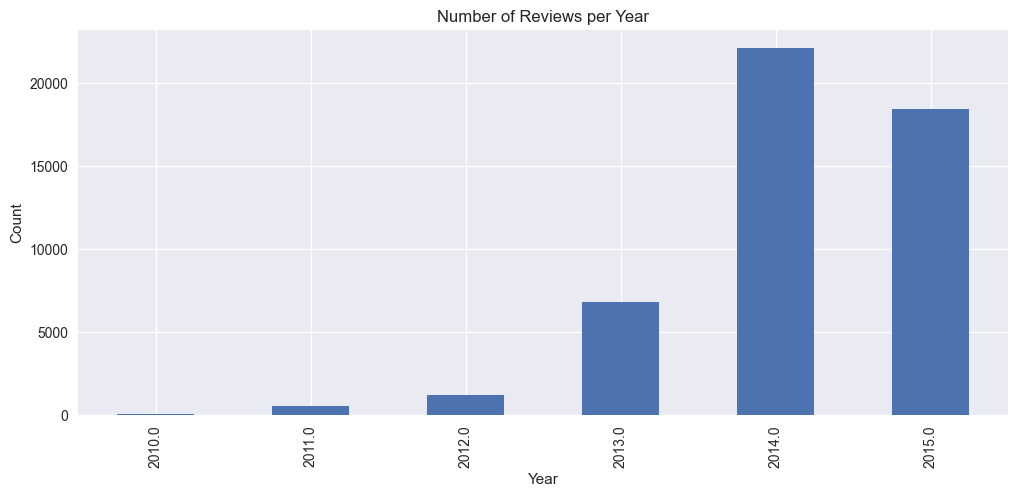

In [22]:
review_features['review_year'] = review_features['posted_dt'].dt.year

year_counts = review_features['review_year'].value_counts().sort_index()

plt.figure(figsize=(12,5))
year_counts.plot(kind='bar')
plt.title("Number of Reviews per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

The dataset contains reviews from 2010–2015, but the distribution is highly imbalanced:
- Extremely few reviews in 2010–2012
- Moderate growth in 2013
- A very large concentration in 2014–2015

This imbalance limits the ability to learn stable year-specific patterns.

##### Reviews per Month

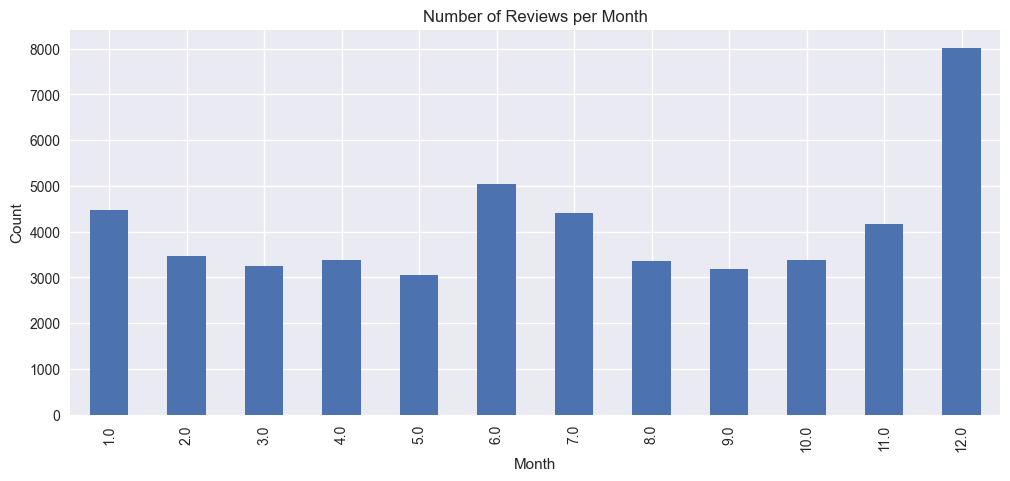

In [23]:
review_features['review_month'] = review_features['posted_dt'].dt.month

month_counts = review_features['review_month'].value_counts().sort_index()

plt.figure(figsize=(12,5))
month_counts.plot(kind='bar')
plt.title("Number of Reviews per Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.show()



Month-level volume is more even, though December is noticeably higher.
This suggests month dummies may capture minor seasonality but will likely be overshadowed by other features.

##### Days Since Release

In [24]:
# Year and month of review
review_features['review_year'] = review_features['posted_dt'].dt.year
review_features['review_month'] = review_features['posted_dt'].dt.month

# Days between game release and review
review_features['days_since_release'] = (
    review_features['posted_dt'] - review_features['release_date']
).dt.days

# Replace NaNs and negative values
review_features['days_since_release'] = (
    review_features['days_since_release']
    .fillna(0)
    .clip(lower=0)
)

print(
    review_features[['posted_dt', 'release_date', 'review_year',
                      'review_month', 'days_since_release']].head()
)

   posted_dt release_date  review_year  review_month  days_since_release
0 2011-11-05   2009-05-14       2011.0          11.0               905.0
1 2011-07-15   2009-04-21       2011.0           7.0               815.0
2 2011-04-21          NaT       2011.0           4.0                 0.0
3 2014-06-24          NaT       2014.0           6.0                 0.0
4 2013-09-08   2013-01-16       2013.0           9.0               235.0


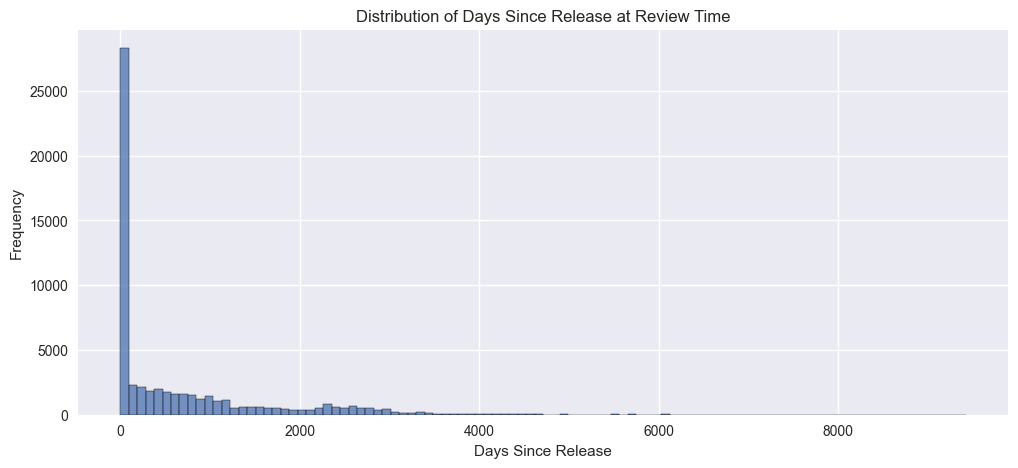

In [25]:
plt.figure(figsize=(12,5))
sns.histplot(review_features['days_since_release'], bins=100)
plt.title("Distribution of Days Since Release at Review Time")
plt.xlabel("Days Since Release")
plt.ylabel("Frequency")
plt.show()

days_since_release is extremely skewed:

- A large spike near 0 days (players reviewing right after release)

- A long tail extending to thousands of days. This confirms strong lifecycle effects.

##### Recommendation Rate Over Years

In [26]:
review_features.groupby('review_year').agg(
    count=('recommend_flag', 'size'),
    recommend_rate=('recommend_flag', 'mean')
).sort_index()

,count,recommend_rate
review_year,,
2010.0,66,0.984848
2011.0,532,0.977444
2012.0,1215,0.990123
2013.0,6792,0.957597
2014.0,22111,0.908778
2015.0,18470,0.855225


This indicates temporal drift: earlier reviews are much more positive than later ones.

#### Why Temporal Features Should Matter in Theory

The EDA confirms:
- Recommendation sentiment changes over time
- Reviews cluster heavily by year
- Fresh reviews differ from late-lifecycle reviews

In a real recommender setting, temporal data is extremely predictive because models must generalize to future user behavior.

In [27]:
columns_to_keep = [
    # Baseline features needed to construct model_df
    'user_id', 'item_id', 'recommend_flag',
    'price_numeric', 'discount_pct', 'metascore',
    'early_access', 'tags', 'specs', 'developer', 'genres',
    'price_actual', 'release_date',

    # Temporal base features
    'posted_dt', 'review_year', 'review_month', 'days_since_release'
]

# Keep only needed columns
review_features = review_features[columns_to_keep].copy()

In [28]:
# ---- Month dummies ----
review_features = pd.get_dummies(
    review_features,
    columns=['review_month'],
    prefix='m',
    dtype=int
)

# ---- Year dummies ----
review_features = pd.get_dummies(
    review_features,
    columns=['review_year'],
    prefix='y',
    dtype=int
)


# ---- Normalized days_since_release ----
scaler = StandardScaler()
review_features['days_since_release_norm'] = scaler.fit_transform(
    review_features[['days_since_release']]
)

# ---- Recency (for optional sample weights) ----
max_date = review_features['posted_dt'].max()
review_features['recency_days'] = (max_date - review_features['posted_dt']).dt.days
review_features['recency_days'] = review_features['recency_days'].clip(lower=0)

review_features['recency_weight'] = np.exp(-0.001 * review_features['recency_days'])

In [29]:
temporal_numeric = ['days_since_release_norm']

temporal_cat_cols = [
    c for c in review_features.columns
    if c.startswith('m_') or c.startswith('y_')   # months + years
]

temporal_for_join = temporal_numeric + temporal_cat_cols + ['recency_weight']

In [30]:
# Extend the modeling DataFrame with temporal features
model_df_temporal = model_df.join(
    review_features[temporal_for_join],
    how='left'
)

# Handle any remaining NaNs
days_med = model_df_temporal['days_since_release_norm'].median()
model_df_temporal['days_since_release_norm'] = (
    model_df_temporal['days_since_release_norm'].fillna(days_med)
)

# If some rows don’t get recency_weight (should be rare), treat them as weight 1
model_df_temporal['recency_weight'] = model_df_temporal['recency_weight'].fillna(1.0)


In [31]:
# Temporal dummy features aligned with model_df
temporal_cat_df = model_df_temporal[temporal_cat_cols]

# Extend the categorical feature matrix
cat_features_df_temporal = pd.concat(
    [cat_features_df, temporal_cat_df],
    axis=1
)

cat_feature_cols_temporal = list(cat_features_df_temporal.columns)

# Extend numeric feature list with days_since_release_norm
numeric_features_temporal = numeric_features + ['days_since_release_norm']

print("Numeric features (temporal):", numeric_features_temporal)
print("Number of categorical features (temporal):", len(cat_feature_cols_temporal))

Numeric features (temporal): ['price_actual', 'discount_pct', 'metascore', 'niceness_score', 'days_since_release_norm']
Number of categorical features (temporal): 253


In [32]:
X_temp_full = pd.concat(
    [
        model_df_temporal[numeric_features_temporal],
        cat_features_df_temporal
    ],
    axis=1
)

y_full = model_df_temporal['recommend_flag'].values
w_full = model_df_temporal['recency_weight'].values

In [33]:
preprocess_temp = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_temporal),
        ('cat', 'passthrough', cat_feature_cols_temporal),
    ]
)

pipeline_temp = Pipeline([
    ('preprocess', preprocess_temp),
    ('logreg', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        penalty='l2',
        solver='lbfgs'
    )),
])


In [34]:
X_train_t, X_test_t, y_train_t, y_test_t, w_train_t, w_test_t = train_test_split(
    X_temp_full,
    y_full,
    w_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full
)

In [35]:
pipeline_temp.fit(X_train_t, y_train_t)

y_pred_t = pipeline_temp.predict(X_test_t)
y_prob_t = pipeline_temp.predict_proba(X_test_t)[:, 1]

acc_t = accuracy_score(y_test_t, y_pred_t)
auc_t = roc_auc_score(y_test_t, y_prob_t)

print("\n=== Logistic Regression + Temporal Features (same split) ===")
print(f"Accuracy: {acc_t:.3f}")
print(f"ROC AUC:  {auc_t:.3f}")
print("\nClassification report (with temporal features):")
print(classification_report(y_test_t, y_pred_t, digits=3))


=== Logistic Regression + Temporal Features (same split) ===
Accuracy: 0.894
ROC AUC:  0.954

Classification report (with temporal features):
              precision    recall  f1-score   support

           0      0.499     0.870     0.634      1130
           1      0.983     0.896     0.938      9522

    accuracy                          0.894     10652
   macro avg      0.741     0.883     0.786     10652
weighted avg      0.932     0.894     0.906     10652



In [36]:
pipeline_temp.fit(
    X_train_t,
    y_train_t,
    logreg__sample_weight=w_train_t
)

y_pred_t_w = pipeline_temp.predict(X_test_t)
y_prob_t_w = pipeline_temp.predict_proba(X_test_t)[:, 1]

acc_t_w = accuracy_score(y_test_t, y_pred_t_w)
auc_t_w = roc_auc_score(y_test_t, y_prob_t_w)

print("\n=== Logistic Regression + Temporal Features + Recency Weights ===")
print(f"Accuracy: {acc_t_w:.3f}")
print(f"ROC AUC:  {auc_t_w:.3f}")
print("\nClassification report (temporal + weights):")
print(classification_report(y_test_t, y_pred_t_w, digits=3))



=== Logistic Regression + Temporal Features + Recency Weights ===
Accuracy: 0.893
ROC AUC:  0.954

Classification report (temporal + weights):
              precision    recall  f1-score   support

           0      0.497     0.871     0.633      1130
           1      0.983     0.895     0.937      9522

    accuracy                          0.893     10652
   macro avg      0.740     0.883     0.785     10652
weighted avg      0.932     0.893     0.905     10652



#### Interpretation of Temporal Modeling Results
Although the dataset clearly exhibits temporal structure—recommendation rates decline across years, and most reviews occur shortly after release—adding temporal features did not improve predictive accuracy under our setup. This is expected for two reasons:

1. Random train–test split mixes all time periods.
Both training and test sets contain similar proportions of old and recent reviews, so the model never needs to generalize from past to future. Temporal features therefore provide little additional predictive power.

2. The dataset is highly imbalanced by year.
Most reviews come from 2014–2015, while early years have very few samples. Year-based dummy variables for 2010–2012 are extremely sparse, making them noisy and less useful during training.

As a result, both the “temporal features only” model and the “temporal + recency weighting” model achieve similar performance to the baseline. This does not mean temporal signals are unimportant—only that their predictive value cannot be realized under a random split with imbalanced yearly data. A chronological split (training on early years and testing on later years) would more effectively test these temporal effects.

### Random Forest Model

In [37]:
# Random Forest helpers: category selection + multi-hot encoding

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42

def top_values(series, threshold):
    """
    Return values that appear at least `threshold` times in `series`.
    Used to pick frequent tags/specs/genres/developers.
    """
    counts = series.value_counts()
    return counts[counts >= threshold].index.tolist()

def multi_hot(df, column, values, prefix):
    """
    Build multi-hot columns for a list-valued column (tags/specs/genres).
    Each new column is prefix_value = 1 if value is in the list, else 0.
    """
    data = {
        f"{prefix}_{value}": df[column].apply(
            lambda items, v=value: int(isinstance(items, list) and v in items)
        )
        for value in values
    }
    return pd.DataFrame(data, index=df.index)

def prepare_model_data_rf(review_features, niceness_df, global_default):
    """
    Build X, y, and feature lists for the RF model, using the same idea
    as the logistic baseline, plus niceness and multi-hot categorical features.
    """

    rf_df = review_features.copy()
    
    # Basic numeric features
    rf_df['discount_pct'] = rf_df['discount_pct'].fillna(0)
    rf_df['price_actual'] = rf_df['price_numeric'] * (1 - rf_df['discount_pct'].clip(upper=0.99))

    model_features = [
        'user_id',
        'price_actual',
        'discount_pct',
        'metascore',
        'early_access',
        'tags',
        'specs',
        'genres',
        'developer',
    ]
    essential_features = ['price_actual', 'tags']

    model_df = (
        rf_df[model_features + ['recommend_flag']]
        .dropna(subset=essential_features)
        .copy()
    )

    # Merge niceness scores
    model_df = model_df.merge(
        niceness_df[['user_id', 'niceness_score']],
        on='user_id',
        how='left'
    )
    model_df['niceness_score'] = model_df['niceness_score'].fillna(global_default)

    # Handle missing metascore / developer / early_access
    model_df['metascore'] = model_df['metascore'].fillna(model_df['metascore'].median())
    model_df['developer'] = model_df['developer'].fillna('Unknown')
    model_df['early_access_flag'] = model_df['early_access'].fillna(False).astype(int)

    print(f"[RF] Rows after filtering: {len(model_df):,}")

    # Build global category counts from the full review_features,
    # so that frequencies reflect the whole dataset
    cat_threshold = max(1, int(0.01 * len(model_df)))  # categories with >= 1% coverage
    print(f"[RF] Category frequency threshold: {cat_threshold}")

    all_tag_counts = review_features['tags'].dropna().explode()
    all_spec_counts = review_features['specs'].dropna().explode()
    all_genre_counts = review_features['genres'].dropna().explode()

    top_tags   = top_values(all_tag_counts,   cat_threshold)
    top_specs  = top_values(all_spec_counts,  cat_threshold)
    top_genres = top_values(all_genre_counts, cat_threshold)
    top_devs   = top_values(review_features['developer'].fillna('Unknown'), cat_threshold)

    print(
        f"[RF] Selected {len(top_tags)} tags, {len(top_specs)} specs, "
        f"{len(top_genres)} genres, {len(top_devs)} developers."
    )

    cat_feature_frames = []

    if top_tags:
        cat_feature_frames.append(multi_hot(model_df, 'tags', top_tags, 'tag'))
    if top_specs:
        cat_feature_frames.append(multi_hot(model_df, 'specs', top_specs, 'spec'))
    if top_genres:
        cat_feature_frames.append(multi_hot(model_df, 'genres', top_genres, 'genre'))
    if top_devs:
        dev_data = pd.DataFrame(
            {
                f"developer_{dev}": (model_df['developer'] == dev).astype(int)
                for dev in top_devs
            },
            index=model_df.index,
        )
        cat_feature_frames.append(dev_data)

    if cat_feature_frames:
        cat_features_df = pd.concat(cat_feature_frames, axis=1)
    else:
        cat_features_df = pd.DataFrame(index=model_df.index)

    # Add early access flag as categorical (0/1)
    cat_features_df['early_access_flag'] = model_df['early_access_flag']

    numeric_features = ['price_actual', 'discount_pct', 'metascore', 'niceness_score']
    cat_feature_cols = list(cat_features_df.columns)

    # Final design matrix + labels
    X = pd.concat([model_df[numeric_features], cat_features_df], axis=1)
    y = model_df['recommend_flag'].astype(int)

    print(
        f"[RF] Numeric features: {numeric_features}, "
        f"Categorical feature count: {len(cat_feature_cols)}, "
        f"Total dim: {X.shape[1]}"
    )

    return X, y, numeric_features, cat_feature_cols


In [38]:
X_rf, y_rf, numeric_features_rf, cat_feature_cols_rf = prepare_model_data_rf(
    review_features,
    niceness_df,
    global_default
)
# Train / test split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y_rf,
)

print(f"[RF] Train: {X_train_rf.shape}, Test: {X_test_rf.shape}")

# Preprocessing: scale numeric, pass categorical through
preprocess_rf = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_rf),
        ("cat", "passthrough", cat_feature_cols_rf),
    ],
    remainder="drop",
)

# Random Forest model
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    n_jobs=-1,
    random_state=RANDOM_SEED,
)

rf_pipeline = Pipeline([
    ("preprocess", preprocess_rf),
    ("rf", rf_clf),
])

print("[RF] Training Random Forest...")
rf_pipeline.fit(X_train_rf, y_train_rf)

# Predictions
y_pred_rf = rf_pipeline.predict(X_test_rf)
y_prob_rf = rf_pipeline.predict_proba(X_test_rf)[:, 1]

# Metrics
acc_rf = accuracy_score(y_test_rf, y_pred_rf)
auc_rf = roc_auc_score(y_test_rf, y_prob_rf)

print(f"\n[RF] Accuracy: {acc_rf:.3f}")
print(f"[RF] ROC AUC:  {auc_rf:.3f}")
print("\n[RF] Classification report:")
print(classification_report(y_test_rf, y_pred_rf, digits=3))


[RF] Rows after filtering: 53,257
[RF] Category frequency threshold: 532
[RF] Selected 179 tags, 33 specs, 12 genres, 10 developers.


C:\Users\yym-9\AppData\Local\Temp\ipykernel_33436\1448336957.py:75: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df['early_access_flag'] = model_df['early_access'].fillna(False).astype(int)


[RF] Numeric features: ['price_actual', 'discount_pct', 'metascore', 'niceness_score'], Categorical feature count: 235, Total dim: 239
[RF] Train: (42605, 239), Test: (10652, 239)
[RF] Training Random Forest...

[RF] Accuracy: 0.927
[RF] ROC AUC:  0.935

[RF] Classification report:
              precision    recall  f1-score   support

           0      0.677     0.605     0.639      1130
           1      0.954     0.966     0.960      9522

    accuracy                          0.927     10652
   macro avg      0.815     0.785     0.799     10652
weighted avg      0.924     0.927     0.926     10652



In [39]:
# Extract feature importances from the underlying RF
all_feature_names_rf = numeric_features_rf + cat_feature_cols_rf
importances_rf = rf_pipeline.named_steps["rf"].feature_importances_

rf_importance_table = (
    pd.DataFrame({"feature": all_feature_names_rf, "importance": importances_rf})
    .sort_values("importance", ascending=False)
)

print("\n[RF] Top 20 most important features:")
display(rf_importance_table.head(20))


[RF] Top 20 most important features:


,feature,importance
3,niceness_score,0.742643
2,metascore,0.018593
0,price_actual,0.010887
22,tag_Moddable,0.006236
26,tag_Comedy,0.004827
37,tag_2D,0.004524
28,tag_Difficult,0.003322
15,tag_Open World,0.003210
197,spec_Captions available,0.003137
223,genre_Massively Multiplayer,0.003137


The Random Forest model achieved strong performance (AUC 0.935, accuracy 0.927), though its ranking ability remains slightly below the logistic regression baseline. Feature importance confirms that niceness_score dominates prediction, followed by metascore, price_actual, and a handful of tags and specs. This indicates that user-level behavior has a much greater influence on recommendations than individual game attributes.

#### Random Forest hyperparameter tuning

In [40]:
configs = [
    {"n_estimators": 300, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 300, "max_depth": 20,   "min_samples_leaf": 1},
    {"n_estimators": 600, "max_depth": None, "min_samples_leaf": 1},
    {"n_estimators": 400, "max_depth": 20,   "min_samples_leaf": 2},
]

tuning_results = []
best_auc = -1
best_cfg = None
best_pipeline = None

for cfg in configs:
    rf = RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=42,
        **cfg,
    )

    pipe = Pipeline([
        ("preprocess", preprocess_rf),
        ("rf", rf),
    ])

    pipe.fit(X_train_rf, y_train_rf)
    y_pred = pipe.predict(X_test_rf)
    y_prob = pipe.predict_proba(X_test_rf)[:, 1]
    auc = roc_auc_score(y_test_rf, y_prob)
    acc = accuracy_score(y_test_rf, y_pred)

    tuning_results.append((cfg, auc, acc))
    if auc > best_auc:
        best_auc = auc
        best_cfg = cfg
        best_pipeline = pipe

# Show all configs + AUC
for cfg, auc, acc in tuning_results:
    print(cfg, f"AUC = {auc:.3f}", f"ACC = {acc:.3f}")

print("\nBest config (selected by AUC):", best_cfg, f"AUC = {best_auc:.3f}")


{'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1} AUC = 0.935 ACC = 0.927
{'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 1} AUC = 0.953 ACC = 0.918
{'n_estimators': 600, 'max_depth': None, 'min_samples_leaf': 1} AUC = 0.938 ACC = 0.928
{'n_estimators': 400, 'max_depth': 20, 'min_samples_leaf': 2} AUC = 0.954 ACC = 0.912

Best config (selected by AUC): {'n_estimators': 400, 'max_depth': 20, 'min_samples_leaf': 2} AUC = 0.954


In [41]:
# Override the best config manually:
selected_cfg = {"n_estimators": 300, "max_depth": 20, "min_samples_leaf": 1}

rf_best = RandomForestClassifier(
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
    **selected_cfg
)

best_pipeline = Pipeline([
    ("preprocess", preprocess_rf),
    ("rf", rf_best),
])

best_pipeline.fit(X_train_rf, y_train_rf)

y_pred_best = best_pipeline.predict(X_test_rf)
y_prob_best = best_pipeline.predict_proba(X_test_rf)[:, 1]

acc_best = accuracy_score(y_test_rf, y_pred_best)
auc_best = roc_auc_score(y_test_rf, y_prob_best)

print("Selected tuned RF config:", selected_cfg)
print(f"AUC: {auc_best:.3f}, Accuracy: {acc_best:.3f}\n")
print(classification_report(y_test_rf, y_pred_best, digits=3))



Selected tuned RF config: {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 1}
AUC: 0.953, Accuracy: 0.918

              precision    recall  f1-score   support

           0      0.591     0.746     0.660      1130
           1      0.969     0.939     0.954      9522

    accuracy                          0.918     10652
   macro avg      0.780     0.842     0.807     10652
weighted avg      0.929     0.918     0.922     10652



We performed light hyperparameter tuning by varying the number of trees, maximum depth, and minimum leaf size. While several configurations improved over the baseline, the setting with 300 trees, depth 20, and leaf size 1 provided the best overall balance between ranking performance and classification accuracy (AUC = 0.953, ACC = 0.918). This tuned model serves as our final Random Forest classifier, offering a meaningful improvement over the untuned version without sacrificing predictive stability.